<div align='center'>
    <h1>Tugas Besar Dasar Kecerdasan Artifisial</h1>
    <h2>Kelas &nbsp;: IF 04-03</h2>

| **Nama** | **NIM** |
|---|---|
| A’ilah Nailul Fa’izah | 103072400042 |
| Nayyara Aurelia Putri | 103072400097 |
| Jingga Jil Carissa | 103072400121 |
| Bethari Nevyta Amaries | 103072430016 |

</div>


### Soal 1 `(Total Bobot: 100 Poin)`

---

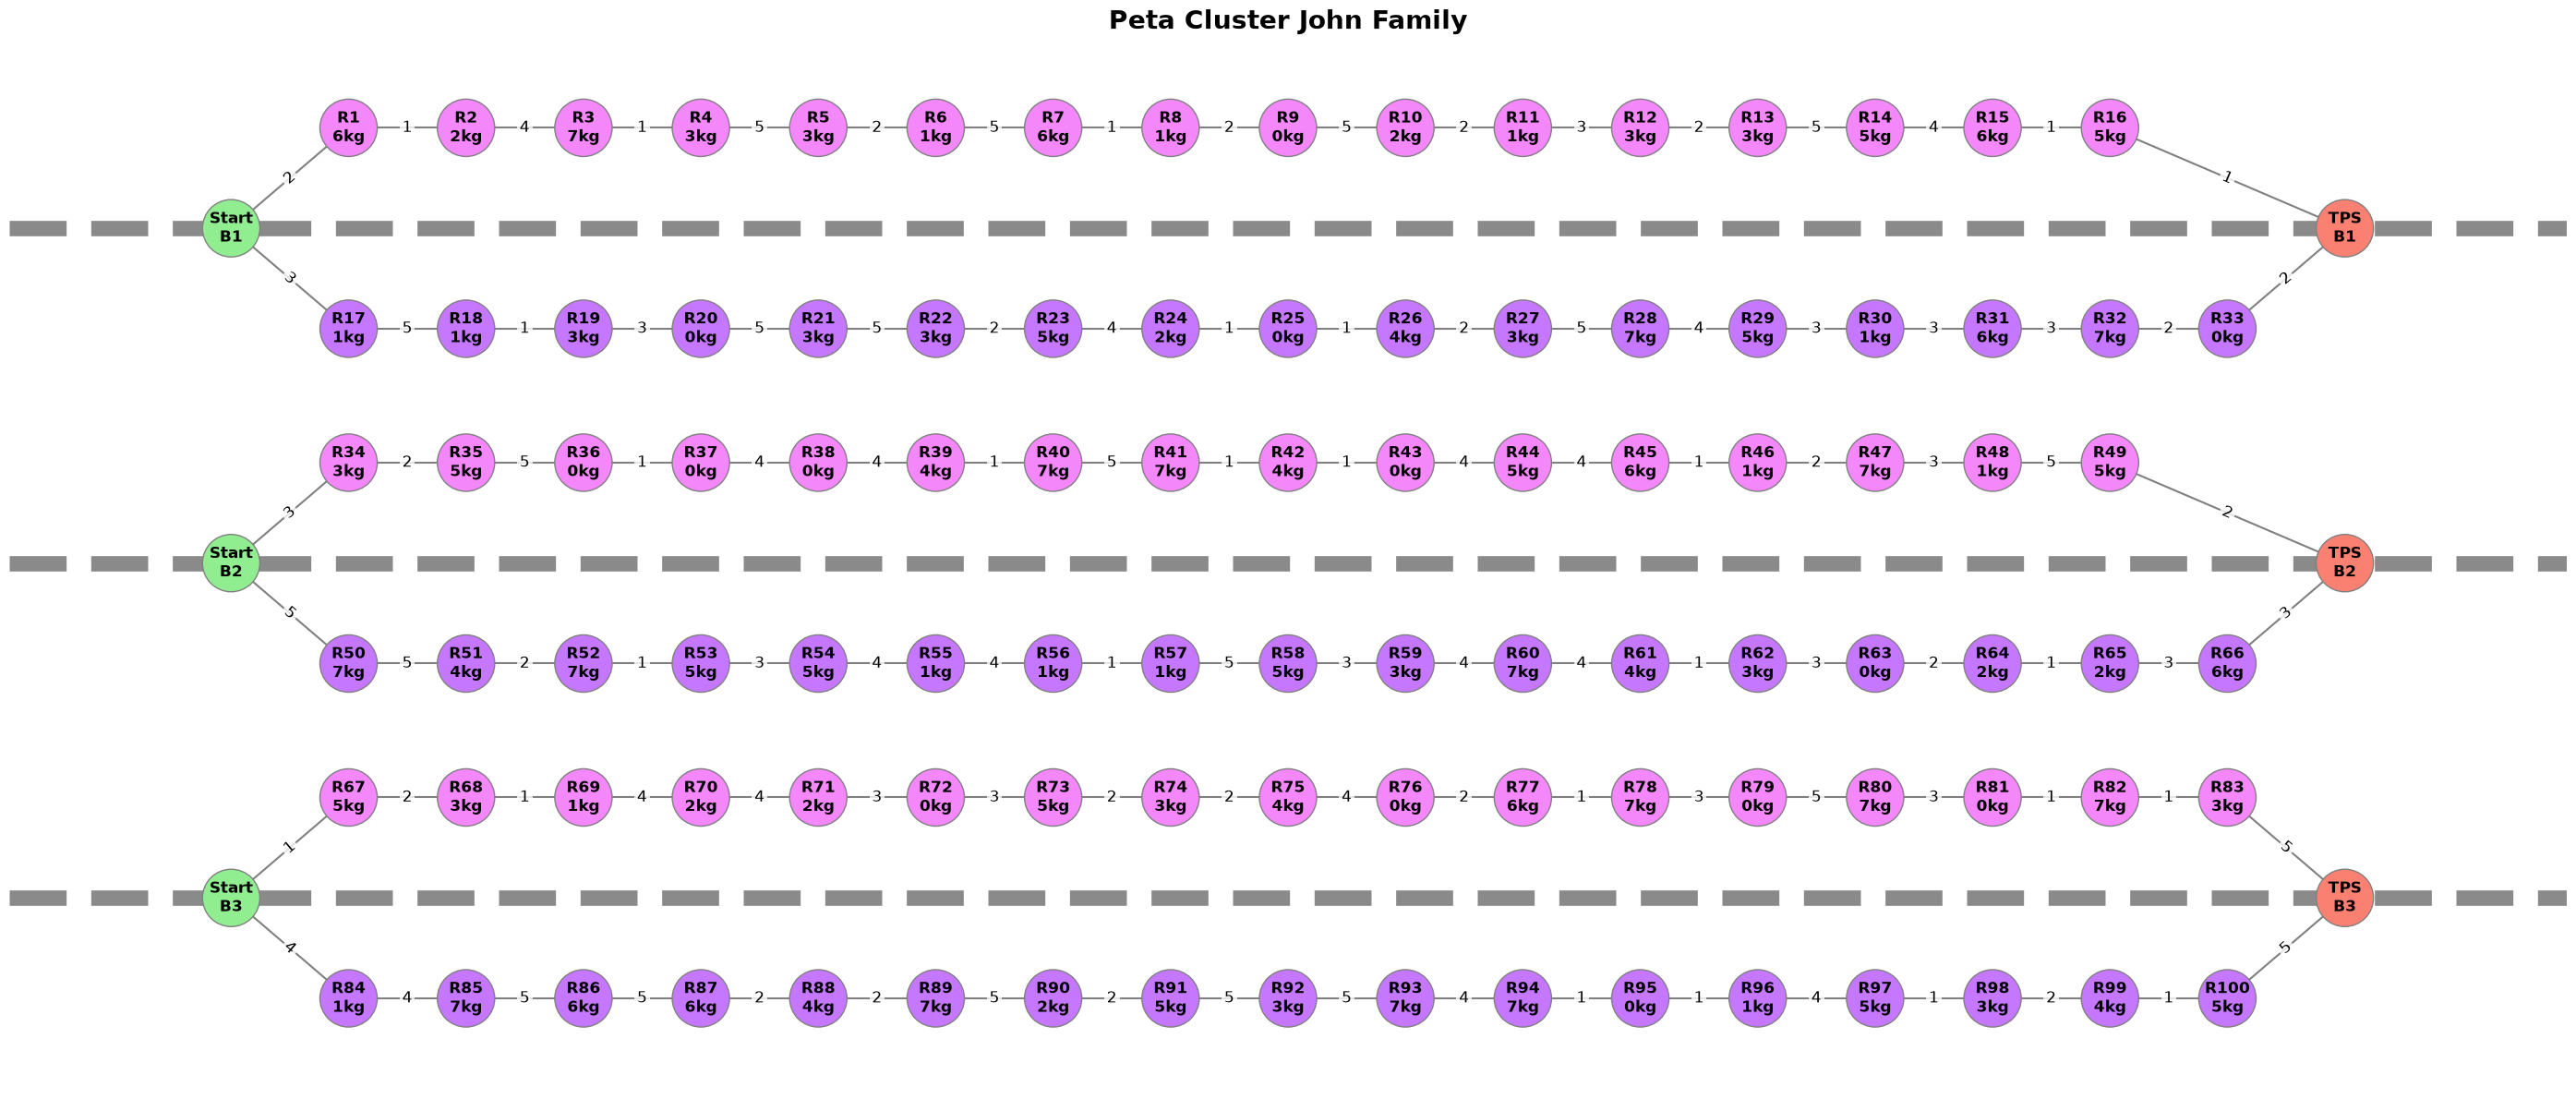


   PENENTUAN RUTE TERBAIK GEROBAK — ALGORITMA A*

─────────────────────────────────────────────────────────────────
  📦 BLOK 1
─────────────────────────────────────────────────────────────────

  Jalur Atas | Total Jarak A*: 46 satuan
  Rute  : Start_B1 → R1 → R2 → R3 → R4 → R5 → R6 → R7 → R8 → R9 ... → TPS_B1
  Keputusan A* saat gerobak penuh:
    • Di R3 (15kg) → TPS_B1 (jarak: 39 satuan | hemat: +0 satuan) ✅ TPS Blok Sudah Optimal
    • Di R7 (13kg) → TPS_B1 (jarak: 26 satuan | hemat: +0 satuan) ✅ TPS Blok Sudah Optimal
    • Di R14 (15kg) → TPS_B1 (jarak: 6 satuan | hemat: +0 satuan) ✅ TPS Blok Sudah Optimal
    • Di R16 (11kg) → TPS_B1 (jarak: 1 satuan | hemat: +0 satuan) ✅ TPS Blok Sudah Optimal

  Jalur Bawah | Total Jarak A*: 54 satuan
  Rute  : Start_B1 → R17 → R18 → R19 → R20 → R21 → R22 → R23 → R24 → R25 ... → TPS_B1
  Keputusan A* saat gerobak penuh:
    • Di R22 (11kg) → TPS_B1 (jarak: 32 satuan | hemat: +0 satuan) ✅ TPS Blok Sudah Optimal
    • Di R26 (11kg) → TPS_B1 (ja

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import math

# 1. INISIALISASI ATURAN, KAPASITAS, DAN HEURISTIK ===
kapasitas_gerobak = 15
kapasitas_truk = 200
kapasitas_max_tps = 450
akumulasi_sampah_tps = {"TPS_B1" : 0, "TPS_B2": 0, "TPS_B3": 0}

# [HEURISTIK] : Jika muatan sudah >= 11kg, gerobak akan panggil truk sebelum jalan agar tidak stuck
batas_heuristik = 11 

# List of Dictionary 3 Blok (100 Rumah dibagi 2 jalur: atas dan bawah) = 33 + 33 + 34 = 100 Rumah
blok_config = [
    {'id': 1, 'top_range': range(1, 17),  'bot_range': range(17, 34),  'y_pos': 9},
    {'id': 2, 'top_range': range(34, 50), 'bot_range': range(50, 67),  'y_pos': 5},
    {'id': 3, 'top_range': range(67, 84), 'bot_range': range(84, 101), 'y_pos': 1}
]


G = nx.Graph()
pos = {}
node_labels = {}
node_colors = []

# 2. MEMBUAT PETA DESA
for blok in blok_config:
    s_node = f"Start_B{blok['id']}" # Titik Start Gerobak per Blok
    t_node = f"TPS_B{blok['id']}" # Titik TPS per Blok
    
    # membuat titik start
    G.add_node(s_node, type='start', sampah=0)
    pos[s_node] = (0, blok['y_pos']) #Titik start disimpan di koordinat (0, y)
    node_labels[s_node] = f"Start\nB{blok['id']}" 
    
    # menyusun rumah berjejer
    def bangun_jalur(range_rumah, tipe_jalur):
        offset_y_atas = 1.2
        offset_y_bawah = -1.2
        titik_sebelumnya = s_node
        max_x = 0
        for idx, i in enumerate(range_rumah):
            nama_rumah = f"R{i}"
            berat_sampah = random.randint(0, 7) # Acak ukuran sampah 0-7 kg
            jarak_jalan = random.randint(1, 5)  # Acak jarak 1-5 satuan per rumah
            
            G.add_node(nama_rumah, type=tipe_jalur, sampah=berat_sampah)
            G.add_edge(titik_sebelumnya, nama_rumah, weight=jarak_jalan)
            
            x_pos = (idx + 1) * 3 # Koordinat x berjarak 3 satuan per rumah
            if tipe_jalur == 'atas':
                pos[nama_rumah] = (x_pos, blok['y_pos'] + offset_y_atas)
            else:
                pos[nama_rumah] = (x_pos, blok['y_pos'] + offset_y_bawah)
            
            node_labels[nama_rumah] = f"{nama_rumah}\n{berat_sampah}kg"
            
            titik_sebelumnya = nama_rumah
            max_x = max(max_x, x_pos) # Menyimpan koordinat paling besar (jauh) / ujung
            
        # penghubung rumah terakhir ke TPS
        jarak_ke_tps = random.randint(1, 5) # Acak jarak 1-5 satuan TPS

        G.add_edge(titik_sebelumnya, t_node, weight=jarak_ke_tps)
        return max_x

    # membuat jalur atas dan bawah
    x_terjauh_atas = bangun_jalur(blok['top_range'],'atas')
    x_terjauh_bawah = bangun_jalur(blok['bot_range'],'bawah')
    
    # membuat Titik TPS
    final_x = max(x_terjauh_atas, x_terjauh_bawah) + 3 # Menyimpan koordinat paling besar (jauh) / ujung untuk peletakan TPS

    G.add_node(t_node, type='tps', sampah=0)
    pos[t_node] = (final_x, blok['y_pos'])
    node_labels[t_node] = f"TPS\nB{blok['id']}"


# 3. VISUALISASI PETA
for node, data in G.nodes(data=True):
    tipe = data.get('type')
    if tipe == 'start': node_colors.append('#90EE90')     
    elif tipe == 'tps': node_colors.append('#FA8072')     
    elif tipe == 'atas': node_colors.append("#F487FA")    
    elif tipe == 'bawah': node_colors.append("#C578FF")   

plt.figure(figsize=(28, 12))
ax = plt.gca() #Mengambil axis (mendatar X)

for blok in blok_config:
    ax.axhline(y=blok['y_pos'], color="#8A8A8AFF", linewidth=12, zorder=0, linestyle='--')
    #Mendapat garis horizontal untuk visualisasi jalan tiap blok


nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, edgecolors='gray', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight='bold', ax=ax)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=12, font_color='black',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2), ax=ax
)

plt.title("Peta Cluster John Family", fontsize=20, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

# ALGORITMA A*
# menambahkan koneksi jalan utama antar blok agar A* bisa mengevaluasi TPS dari blok lain sebagai alternatif pembuangan

# Kandidat tujuan
G.add_edge("TPS_B1",   "TPS_B2",   weight=8)
G.add_edge("TPS_B2",   "TPS_B3",   weight=8)
G.add_edge("Start_B1", "Start_B2", weight=6)
G.add_edge("Start_B2", "Start_B3", weight=6)

tps_nodes = ["TPS_B1", "TPS_B2", "TPS_B3"] 

def heuristik_euclidean(node_a, node_b):
    xa, ya = pos[node_a]
    xb, yb = pos[node_b]
    return math.sqrt((xa - xb) ** 2 + (ya - yb) ** 2)

def astar_ke_tujuan(start, goal):
    jalur = nx.astar_path(G, start, goal, heuristic=heuristik_euclidean, weight='weight')
    jarak = nx.astar_path_length(G, start, goal, heuristic=heuristik_euclidean, weight='weight')
    return jalur, jarak

def astar_pilih_tps_terdekat(posisi_gerobak):
    best_tps, best_path, best_jarak = None, [], float('inf')
    for tps in tps_nodes:
        path, jarak = astar_ke_tujuan(posisi_gerobak, tps)
        if jarak < best_jarak:
            best_jarak, best_tps, best_path = jarak, tps, path
    return best_tps, best_path, best_jarak

def rute_astar_gerobak(start, daftar_rumah, tps_blok):
    rute, posisi, total_jarak, muatan, events_astar = [start], start, 0, 0, []

    for rumah in daftar_rumah:
        _, jarak_ke_rumah = astar_ke_tujuan(posisi, rumah)
        total_jarak += jarak_ke_rumah
        rute.append(rumah)
        posisi = rumah
        muatan += G.nodes[rumah]['sampah']

        if muatan >= batas_heuristik:
            tps_dipilih, path_ke_tps, jarak_ke_tps = astar_pilih_tps_terdekat(posisi)
            jarak_default = astar_ke_tujuan(posisi, tps_blok)[1] #Untuk mendapatkan indeks ke-1 yaitu jarak
            events_astar.append({
                'posisi'     : posisi,
                'muatan'     : muatan,
                'tps_dipilih': tps_dipilih,
                'jarak_tps'  : jarak_ke_tps,
                'hemat'      : round(jarak_default - jarak_ke_tps, 2)
            })
            muatan = 0

    tps_akhir, _, jarak_akhir = astar_pilih_tps_terdekat(posisi)
    total_jarak += jarak_akhir
    rute.append(tps_akhir)
    return rute, total_jarak, events_astar

# eksekusi A* per blok
print("\n" + "=" * 70)
print("   PENENTUAN RUTE TERBAIK GEROBAK — ALGORITMA A*")
print("=" * 70)

rute_optimal = {}

for blok in blok_config:
    s_node      = f"Start_B{blok['id']}"
    t_node_blok = f"TPS_B{blok['id']}"
    rumah_atas  = [f"R{i}" for i in blok['top_range']]
    rumah_bawah = [f"R{i}" for i in blok['bot_range']]

    print(f"\n{'─'*65}")
    print(f"  📦 BLOK {blok['id']}")
    print(f"{'─'*65}")

    for nama_jalur, daftar_rumah in [("Atas", rumah_atas), ("Bawah", rumah_bawah)]:
        rute, jarak_total, events = rute_astar_gerobak(s_node, daftar_rumah, t_node_blok)
        rute_optimal[f"B{blok['id']}_{nama_jalur.lower()}"] = rute

        print(f"\n  Jalur {nama_jalur} | Total Jarak A*: {jarak_total} satuan")
        print(f"  Rute  : {' → '.join(rute[:10])} ... → {rute[-1]}")
        if events:
            print(f"  Keputusan A* saat gerobak penuh:")
            for ev in events:
                if ev['hemat'] > 0:
                    tanda = "💡 LEBIH HEMAT"
                else:
                    tanda = "✅ TPS Blok Sudah Optimal"
                
                print(f"    • Di {ev['posisi']} ({ev['muatan']}kg) → {ev['tps_dipilih']} "
                      f"(jarak: {ev['jarak_tps']:.0f} satuan | hemat: {ev['hemat']:+.0f} satuan) {tanda}")


# 4. FUNGSI SIMULASI & LOGIKA HEURISTIK 
print("\n" + "="*70)
print("      SIMULASI PENGANGKUTAN (100 RUMAH)      ")
print("="*70)

def jalankan_gerobak(nama_gerobak, nama_truk, rute_nodes, penanda_jalur):
    muatan_g = 0
    muatan_t = 0
    jarak_g = 0
    jarak_t = 0
    events = [] 
    
    for i in range(len(rute_nodes) - 1):
        asal = rute_nodes[i]
        tujuan = rute_nodes[i+1]
        
        jarak = G[asal][tujuan]['weight']
        sampah_di_depan = G.nodes[tujuan]['sampah']
        
        if muatan_g >= batas_heuristik and "TPS" not in tujuan:
            if (jarak_g - jarak_t) > 0: jarak_t += (jarak_g - jarak_t)
            muatan_t += muatan_g
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] 💡 HEURISTIK! {nama_gerobak} isi {muatan_g}kg di {asal} 🚛 Truk datang sebelum jalan ke {tujuan}."
            })
            muatan_g = 0
            
        jarak_g += jarak
        
        if "TPS" in tujuan:
            muatan_t += muatan_g
            
            # Pengecekan kapasitas TPS
            if akumulasi_sampah_tps[tujuan] + muatan_g > kapasitas_max_tps:
                sisa_slot = kapasitas_max_tps - akumulasi_sampah_tps[tujuan]
                akumulasi_sampah_tps[tujuan] = kapasitas_max_tps

                events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] 🚨 peringatan di {tujuan}! TPS hanya dapat menampung {sisa_slot} lagi. Sisa sampah tertahan!"
                })
            else: 
                akumulasi_sampah_tps[tujuan] += muatan_g
                events.append({
                    'jarak': jarak_g,
                    'pesan': f"[{penanda_jalur}] 🏁 {nama_gerobak} tiba di {tujuan}. Sisa {muatan_g}kg dibuang ke TPS"
                })
            break
            
        if muatan_g + sampah_di_depan <= kapasitas_gerobak:
            muatan_g += sampah_di_depan
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] 🗑️ {nama_gerobak} ambil {sampah_di_depan}kg di {tujuan}. (Total: {muatan_g}/{kapasitas_gerobak}kg)"
            })
        else:
            if (jarak_g - jarak_t) > 0: jarak_t += (jarak_g - jarak_t)
            muatan_t += muatan_g
            events.append({
                'jarak': jarak_g,
                'pesan': f"[{penanda_jalur}] ⚠️ STUCK di {tujuan}! Truk menyusul. Muatan diambil (Isi Truk: {muatan_t}kg)"
            })
            muatan_g = sampah_di_depan 
            
    return jarak_g, jarak_t, muatan_t, events


# 5. LAPORAN 
grand_total_jarak_gerobak = 0
grand_total_jarak_truk = 0
grand_total_sampah = 0
laporan_detail_gerobak = []
laporan_detail_truk = []

for blok in blok_config:
    print(f"\n" + "-"*65)
    print(f" LAPORAN BLOK {blok['id']} (URUTAN WAKTU/JARAK) ")
    print("-"*65)
    
    s_node, t_node = f"Start_B{blok['id']}", f"TPS_B{blok['id']}"
    nama_truk = f"Truk {blok['id']}"
    nama_g_atas, nama_g_bawah = f"Gerobak {blok['id']}A", f"Gerobak {blok['id']}B"
    
    # Rute dari A*
    rute_atas  = rute_optimal[f"B{blok['id']}_atas"]
    rute_bawah = rute_optimal[f"B{blok['id']}_bawah"]
    
    jg_A, jt_A, mt_A, events_A = jalankan_gerobak(nama_g_atas, nama_truk, rute_atas, "Jalur Atas ")
    jg_B, jt_B, mt_B, events_B = jalankan_gerobak(nama_g_bawah, nama_truk, rute_bawah, "Jalur Bawah")
    
    semua_events = events_A + events_B
    semua_events.sort(key=lambda x: x['jarak'])
    for ev in semua_events: print(ev['pesan'])
        
    jarak_truk_blok = max(jt_A, jt_B)
    total_sampah_blok = mt_A + mt_B
    
    print(f"\n📝 REKAP BLOK {blok['id']} | Total Sampah: {total_sampah_blok} kg | Jarak Truk: {jarak_truk_blok}")
    
    laporan_detail_gerobak.extend([
        {"nama": nama_g_atas, "jarak": jg_A, "sampah": mt_A},
        {"nama": nama_g_bawah, "jarak": jg_B, "sampah": mt_B}
    ])
    laporan_detail_truk.append({"nama": nama_truk, "jarak": jarak_truk_blok, "sampah": total_sampah_blok})
    
    grand_total_jarak_gerobak += (jg_A + jg_B)
    grand_total_jarak_truk += jarak_truk_blok
    grand_total_sampah += total_sampah_blok

print("\n" + "="*70)
print("            REPORT PERGERAKAN HARIAN PAK KADES 🧔🏻‍♂️          ")
print("="*70)
for g in laporan_detail_gerobak:
    print(f"{g['nama']:12} | Jarak: {g['jarak']:3} | Sampah: {g['sampah']:3} kg")
print("-" * 55)
for t in laporan_detail_truk:
    print(f"{t['nama']:12} | Jarak: {t['jarak']:3} | Total TPS: {t['sampah']:3} kg")
print("="*70)
print(f"GRAND TOTAL | Sampah: {grand_total_sampah} kg | Truk: {grand_total_jarak_truk} | Gerobak: {grand_total_jarak_gerobak}")


### Soal 2 `(Tambahan Bobot: 50 Poin)`
Menambahkan **jam operasi**, **waktu loading & perjalanan**, serta menghitung **sisa sampah** (rumah tangga, gerobak, truk) ketika jam operasi telah selesai.

**Aturan:**
- A. Gerobak beroperasi 06.00 - 15.00
- B. Truk beroperasi 08.00 - 17.00
- C. Gerobak: loading 2 menit/kg, perjalanan 3 menit/satuan jarak
- D. Truk: loading 2 menit/10kg, perjalanan 3 menit/5 satuan jarak
- E. Hitung waktu yang dihabiskan truk & gerobak
- F. Hitung sisa sampah rumah tangga, truk, dan gerobak setelah jam operasi selesai

   SOAL 2 — JAM OPERASI, ALOKASI WAKTU, DAN SISA SAMPAH

Jam Operasi:
  • Gerobak : 06:00 - 15:00  (540 menit)
  • Truk    : 08:00 - 17:00  (540 menit)

Tarif Waktu:
  • Gerobak -> Loading: 2 menit/kg   | Jalan: 3 menit/satuan jarak
  • Truk    -> Loading: 0.2 menit/kg | Jalan: 0.6 menit/satuan jarak


─────────────────────────────────────────────────────────────────
  📦 BLOK 1 — SIMULASI WAKTU
─────────────────────────────────────────────────────────────────
  [Atas] 🗑️ Gerobak 1A ambil 6kg di R1 pukul 06:18 (muatan 6kg)
  [Atas] 🗑️ Gerobak 1A ambil 2kg di R2 pukul 06:25 (muatan 8kg)
  [Atas] 🗑️ Gerobak 1A ambil 7kg di R3 pukul 06:51 (muatan 15kg)
  [Atas] ⚠️ Gerobak 1A penuh (15kg), dipindahkan ke truk 🚛pukul 07:24
  [Atas] 🗑️ Gerobak 1A lanjut ambil 3kg di R4 (muatan 3kg)
  [Atas] 🗑️ Gerobak 1A ambil 3kg di R5 pukul 07:51 (muatan 6kg)
  [Atas] 🗑️ Gerobak 1A ambil 1kg di R6 pukul 07:59 (muatan 7kg)
  [Atas] 🗑️ Gerobak 1A ambil 6kg di R7 pukul 08:26 (muatan 13kg)
  [Atas] 🗑️ Gerobak 1

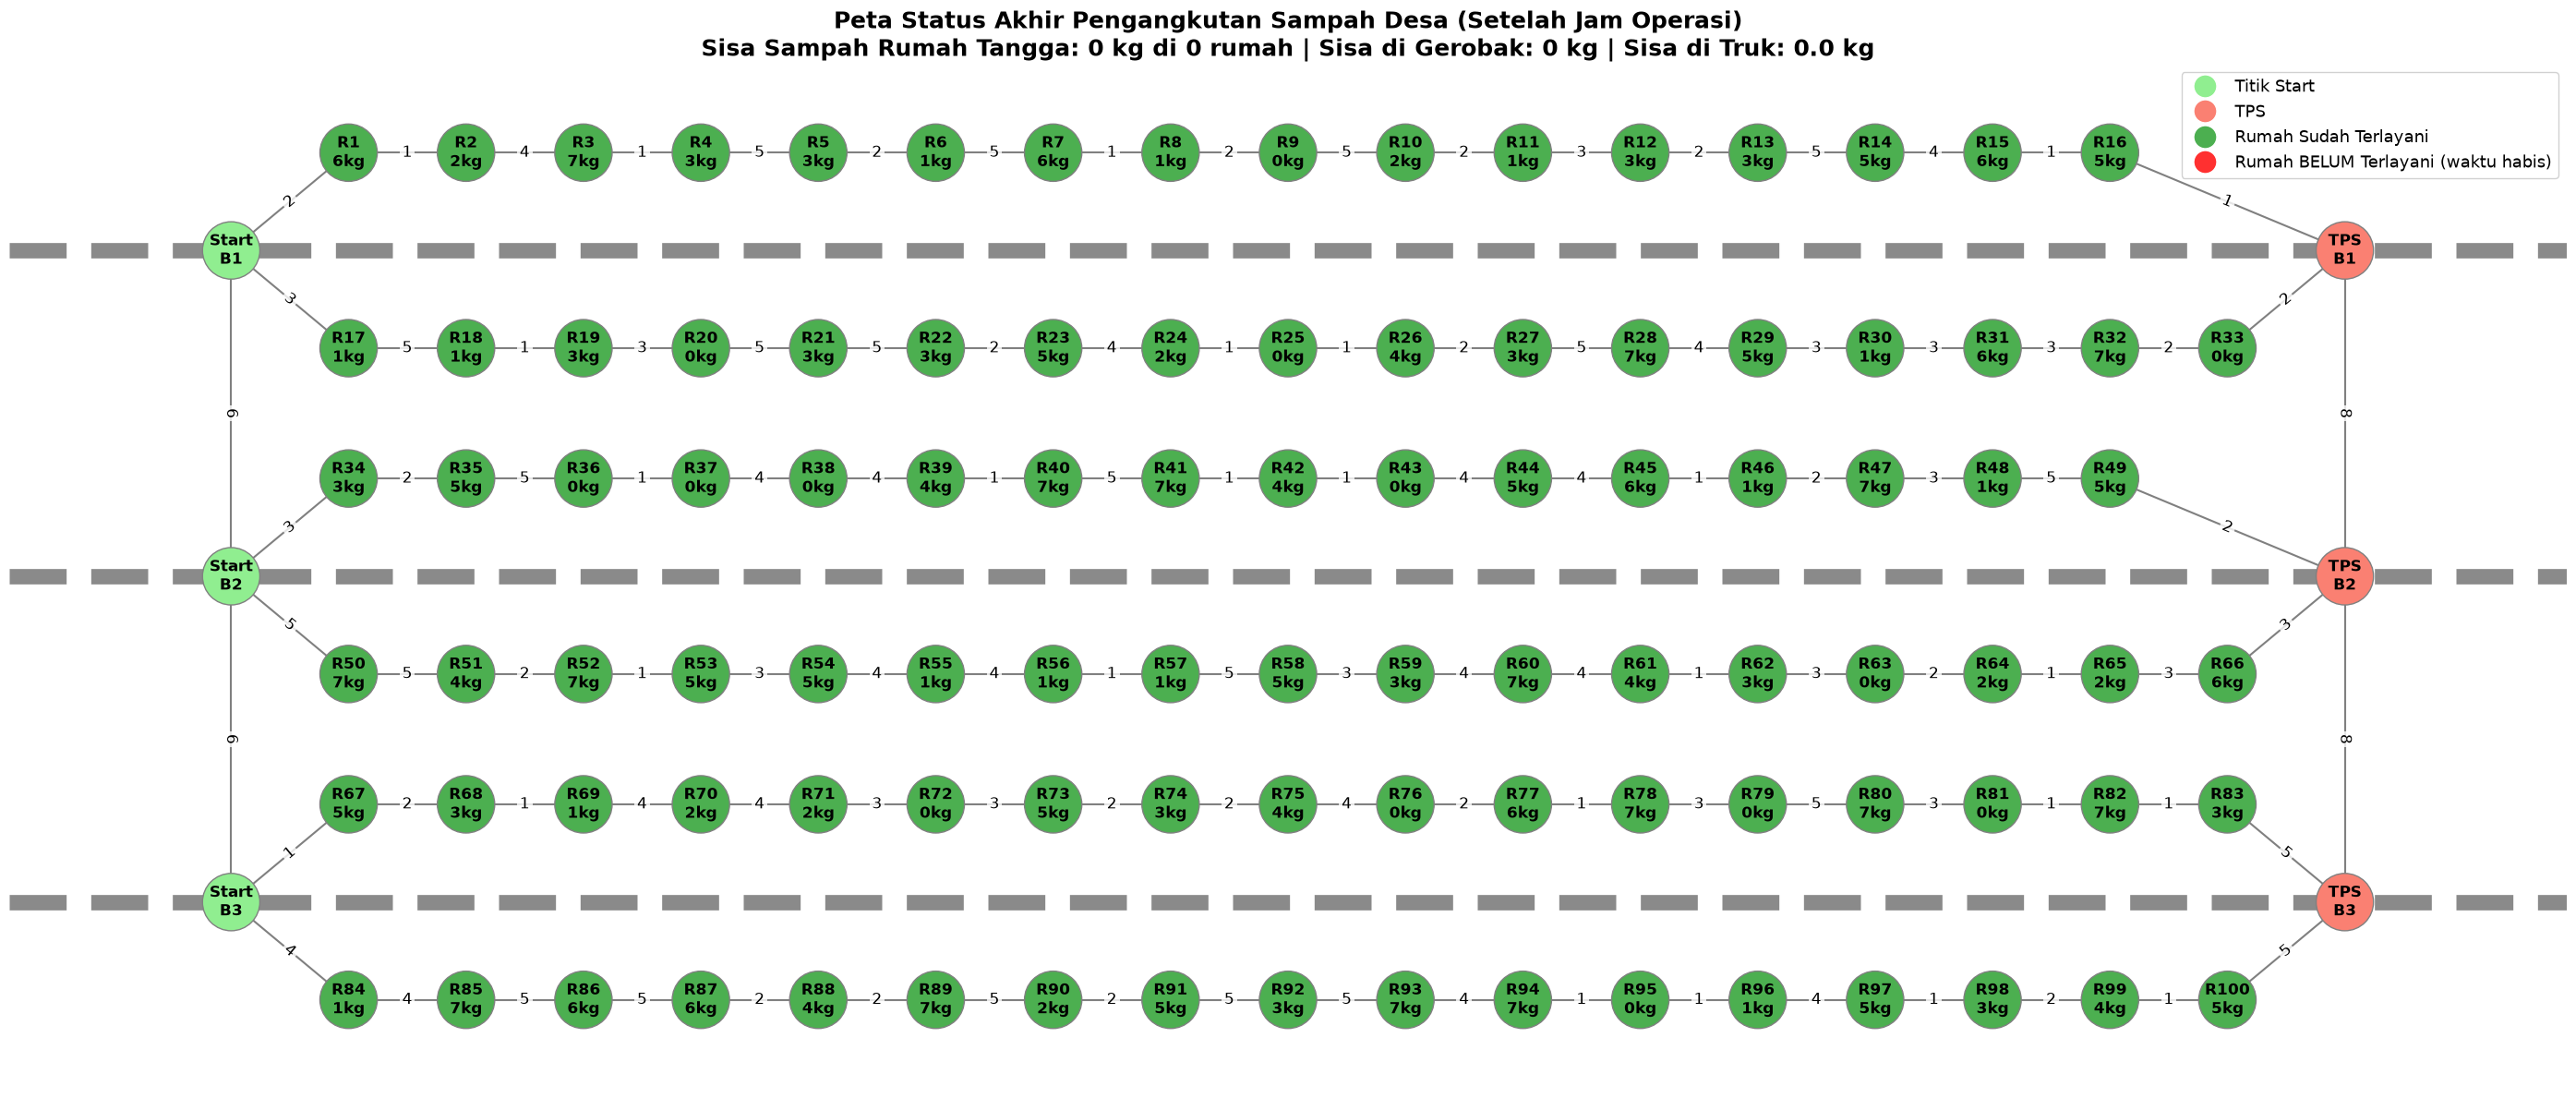

In [13]:
print("=" * 70)
print("   SOAL 2 — JAM OPERASI, ALOKASI WAKTU, DAN SISA SAMPAH")
print("=" * 70)

# A dan B. JAM OPERASI
JAM_MULAI_GEROBAK   = 6 * 60 # 06:00
JAM_SELESAI_GEROBAK = 15 * 60 # 15:00
DURASI_GEROBAK      = JAM_SELESAI_GEROBAK - JAM_MULAI_GEROBAK # 540 menit

JAM_MULAI_TRUK   = 8 * 60 # 08:00
JAM_SELESAI_TRUK = 17 * 60 # 17:00
DURASI_TRUK      = JAM_SELESAI_TRUK - JAM_MULAI_TRUK # 540 menit

# C. WAKTU LOADING & PERJALANAN GEROBAK ===
#    - Loading (di rumah / saat dipindah ke truk / dibuang ke TPS): 2 menit/kg
#    - Perjalanan: 3 menit per 1 satuan jarak
WAKTU_LOADING_GEROBAK_PER_KG    = 2 # menit / kg
WAKTU_JALAN_GEROBAK_PER_SATUAN  = 3 # menit / satuan jarak

# D. WAKTU LOADING & PERJALANAN TRUK ===
#    - Loading di TPS: 2 menit per 10 kg  -> 0.2 menit/kg
#    - Perjalanan: 3 menit per 5 satuan jarak -> 0.6 menit/satuan
WAKTU_LOADING_TRUK_PER_KG       = 2 / 10 # menit / kg
WAKTU_JALAN_TRUK_PER_SATUAN     = 3 / 5 # menit / satuan jarak

def format_jam(menit_sejak_00):
    j = int(menit_sejak_00 // 60) % 24
    m = int(menit_sejak_00 % 60)
    return f"{j:02d}:{m:02d}"

print(f"""
Jam Operasi:
  • Gerobak : {format_jam(JAM_MULAI_GEROBAK)} - {format_jam(JAM_SELESAI_GEROBAK)}  ({DURASI_GEROBAK} menit)
  • Truk    : {format_jam(JAM_MULAI_TRUK)} - {format_jam(JAM_SELESAI_TRUK)}  ({DURASI_TRUK} menit)

Tarif Waktu:
  • Gerobak -> Loading: {WAKTU_LOADING_GEROBAK_PER_KG} menit/kg   | Jalan: {WAKTU_JALAN_GEROBAK_PER_SATUAN} menit/satuan jarak
  • Truk    -> Loading: {WAKTU_LOADING_TRUK_PER_KG} menit/kg | Jalan: {WAKTU_JALAN_TRUK_PER_SATUAN} menit/satuan jarak
""")

# SIMULASI GEROBAK DENGAN BATASAN WAKTU OPERASI 
def jalankan_gerobak_waktu(nama_gerobak, rute_nodes, penanda_jalur):
    waktu, muatan_g, jarak_tempuh, sampah_ke_tps = 0, 0, 0, 0
    rumah_belum, log = [], [] #log = event

    i = 0
    while i < len(rute_nodes) - 1: #menelusuri rute (-1 sebagai batas akhir)
        asal, tujuan = rute_nodes[i], rute_nodes[i + 1]
        jarak       = G[asal][tujuan]['weight']
        waktu_jalan = jarak * WAKTU_JALAN_GEROBAK_PER_SATUAN

        # cek apakah waktu operasi masih cukup untuk berjalan ke node berikutnya
        if waktu + waktu_jalan > DURASI_GEROBAK:
            log.append(f"[{penanda_jalur}] ⏰ {nama_gerobak} kehabisan jam operasi "
                        f"(pukul {format_jam(JAM_MULAI_GEROBAK + waktu)}) sebelum tiba di {tujuan}.")
            # memasukkan rumah yang stuck kedalam list secara bersamaan
            rumah_belum.extend([n for n in rute_nodes[i:] if n.startswith("R")])
            break

        waktu += waktu_jalan
        jarak_tempuh += jarak

        if "TPS" in tujuan:
            waktu_buang = muatan_g * WAKTU_LOADING_GEROBAK_PER_KG
            if waktu + waktu_buang > DURASI_GEROBAK:
                log.append(f"[{penanda_jalur}] ⏰ {nama_gerobak} tiba di {tujuan} tapi waktu "
                            f"tidak cukup untuk loading {muatan_g}kg. Sisa terbawa di gerobak.")
                break

            waktu += waktu_buang
            
            # cek kapasitas tps
            if akumulasi_sampah_tps[tujuan] + muatan_g > kapasitas_max_tps:
                sisa_slot = kapasitas_max_tps - akumulasi_sampah_tps[tujuan]
                if sisa_slot > 0:
                    akumulasi_sampah_tps[tujuan] = kapasitas_max_tps
                    sampah_ke_tps += sisa_slot
                    muatan_g -= sisa_slot
                    log.append(f"[{penanda_jalur}] 🚨 Peringatan! {tujuan} hanya menampung {sisa_slot}kg lagi.")
                else:
                    log.append(f"[{penanda_jalur}] 🚨 {tujuan} penuh total! {muatan_g}kg tertahan di gerobak.")
            else:
                akumulasi_sampah_tps[tujuan] += muatan_g
                sampah_ke_tps += muatan_g
                log.append(f"[{penanda_jalur}] 🏁 {nama_gerobak} buang {muatan_g}kg ke {tujuan} "
                        f"pukul {format_jam(JAM_MULAI_GEROBAK + waktu)}")
                muatan_g = 0
            i += 1
            continue

        sampah_rumah = G.nodes[tujuan]['sampah'] #ngambil sampah dari graf
        waktu_ambil  = sampah_rumah * WAKTU_LOADING_GEROBAK_PER_KG

        if waktu + waktu_ambil > DURASI_GEROBAK:
            log.append(f"[{penanda_jalur}] ⏰ {nama_gerobak} tiba di {tujuan} tapi waktu "
                        f"loading tidak cukup. Sampah {sampah_rumah}kg tidak terangkut.")
            rumah_belum.extend([n for n in rute_nodes[i + 1:] if n.startswith("R")])
            break

        if muatan_g + sampah_rumah <= kapasitas_gerobak:
            muatan_g += sampah_rumah
            waktu    += waktu_ambil
            log.append(f"[{penanda_jalur}] 🗑️ {nama_gerobak} ambil {sampah_rumah}kg di {tujuan} "
                        f"pukul {format_jam(JAM_MULAI_GEROBAK + waktu)} (muatan {muatan_g}kg)")
        else:
            # kalau gerobak penuh dipindahkan ke truk 
            waktu_pindah = muatan_g * WAKTU_LOADING_GEROBAK_PER_KG
            if waktu + waktu_pindah > DURASI_GEROBAK:
                log.append(f"[{penanda_jalur}] ⏰ {nama_gerobak} penuh di {tujuan} tapi waktu "
                            f"tidak cukup untuk transfer ke truk.")
                rumah_belum.append(tujuan)
                rumah_belum.extend([n for n in rute_nodes[i + 2:] if n.startswith("R")])
                break
            waktu += waktu_pindah
            sampah_ke_tps += muatan_g
            log.append(f"[{penanda_jalur}] ⚠️ {nama_gerobak} penuh ({muatan_g}kg), dipindahkan ke truk 🚛"
                        f"pukul {format_jam(JAM_MULAI_GEROBAK + waktu)}")
            muatan_g = sampah_rumah
            waktu += waktu_ambil
            log.append(f"[{penanda_jalur}] 🗑️ {nama_gerobak} lanjut ambil {sampah_rumah}kg di {tujuan} "
                        f"(muatan {muatan_g}kg)")
        i += 1
    return waktu, jarak_tempuh, sampah_ke_tps, muatan_g, rumah_belum, log


# SIMULASI WAKTU UNTUK SETIAP BLOK
rekap_waktu_gerobak = []
rekap_waktu_truk = []
# menjumlahkan semua total sampah dari graf yg berawalan node R (rumah)
total_sampah_rumah_seharusnya = sum(G.nodes[n]['sampah'] for n in G.nodes if n.startswith("R"))

for blok in blok_config:
    print(f"\n{'─'*65}")
    print(f"  📦 BLOK {blok['id']} — SIMULASI WAKTU")
    print(f"{'─'*65}")

    rute_atas = rute_optimal[f"B{blok['id']}_atas"]
    rute_bawah = rute_optimal[f"B{blok['id']}_bawah"]
    nama_truk = f"Truk {blok['id']}"

    waktu_A, jarak_A, sampah_A, sisa_g_A, belum_A, log_A = jalankan_gerobak_waktu(
        f"Gerobak {blok['id']}A", rute_atas, "Atas")
    waktu_B, jarak_B, sampah_B, sisa_g_B, belum_B, log_B = jalankan_gerobak_waktu(
        f"Gerobak {blok['id']}B", rute_bawah, "Bawah")

    # rekap waktu per blok
    for l in log_A + log_B:
        print(" ", l)

    # E. Waktu yang dihabiskan truk: berdasarkan jarak (A*) + loading sampah yang diterima
    sampah_truk_blok = sampah_A + sampah_B
    jarak_truk_blok = max(jarak_A, jarak_B) # jarak tempuh truk berdasarkan jarak max atas dan bawah
    waktu_jalan_truk = jarak_truk_blok * WAKTU_JALAN_TRUK_PER_SATUAN
    waktu_loading_truk = sampah_truk_blok * WAKTU_LOADING_TRUK_PER_KG
    waktu_truk_blok = waktu_jalan_truk + waktu_loading_truk

    sisa_truk_blok = 0
    if waktu_truk_blok > DURASI_TRUK:
        # truk kehabisan waktu (hitung berapa kg yang tidak sempat di-loading / diturunkan)
        sisa_waktu      = DURASI_TRUK - waktu_jalan_truk
        kg_terlayani    = max(sisa_waktu, 0) / WAKTU_LOADING_TRUK_PER_KG
        sisa_truk_blok  = max(sampah_truk_blok - kg_terlayani, 0)
        waktu_truk_blok = DURASI_TRUK
        print(f"  ⏰ {nama_truk} kehabisan jam operasi! Sisa {sisa_truk_blok:.1f} kg belum diturunkan ke TPS.")

    print(f"\n  📝 REKAP WAKTU BLOK {blok['id']}")
    print(f"     Gerobak {blok['id']}A : {format_jam(JAM_MULAI_GEROBAK)} s.d. "
          f"{format_jam(JAM_MULAI_GEROBAK + waktu_A)}  | Waktu pakai: {waktu_A:.0f} menit "
          f"| Jarak: {jarak_A} | Sampah ke TPS: {sampah_A} kg | Sisa di gerobak: {sisa_g_A} kg "
          f"| Rumah belum terlayani: {len(belum_A)}")
    print(f"     Gerobak {blok['id']}B : {format_jam(JAM_MULAI_GEROBAK)} s.d. "
          f"{format_jam(JAM_MULAI_GEROBAK + waktu_B)}  | Waktu pakai: {waktu_B:.0f} menit "
          f"| Jarak: {jarak_B} | Sampah ke TPS: {sampah_B} kg | Sisa di gerobak: {sisa_g_B} kg "
          f"| Rumah belum terlayani: {len(belum_B)}")
    print(f"     {nama_truk:12}: {format_jam(JAM_MULAI_TRUK)} s.d. "
          f"{format_jam(JAM_MULAI_TRUK + waktu_truk_blok)}  | Waktu pakai: {waktu_truk_blok:.1f} menit "
          f"| Jarak: {jarak_truk_blok} | Sampah diterima: {sampah_truk_blok} kg "
          f"| Sisa belum diturunkan: {sisa_truk_blok:.1f} kg")

    rekap_waktu_gerobak.append({"nama": f"Gerobak {blok['id']}A", "waktu": waktu_A, "jarak": jarak_A,
                                 "sampah_terangkut": sampah_A, "sisa_gerobak": sisa_g_A,
                                 "rumah_belum": belum_A})
    rekap_waktu_gerobak.append({"nama": f"Gerobak {blok['id']}B", "waktu": waktu_B, "jarak": jarak_B,
                                 "sampah_terangkut": sampah_B, "sisa_gerobak": sisa_g_B,
                                 "rumah_belum": belum_B})
    rekap_waktu_truk.append({"nama": nama_truk, "waktu": waktu_truk_blok, "jarak": jarak_truk_blok,
                              "sampah_diterima": sampah_truk_blok, "sisa_truk": sisa_truk_blok})

# F. REKAP AKHIR: WAKTU TOTAL & SISA SAMPAH SETELAH JAM OPERASI SELESAI ===
print("\n" + "=" * 70)
print("   REPORT AKHIR — WAKTU OPERASI & SISA SAMPAH")
print("=" * 70)

print("\n  -- Waktu Pakai Gerobak --")
total_waktu_gerobak = 0
total_sisa_gerobak  = 0
total_rumah_belum   = 0
for g in rekap_waktu_gerobak:
    print(f"  {g['nama']:14} | Waktu: {g['waktu']:6.0f} menit | Sisa di gerobak: {g['sisa_gerobak']:4} kg "
          f"| Rumah belum diambil: {len(g['rumah_belum']):2}")
    total_waktu_gerobak += g['waktu']
    total_sisa_gerobak  += g['sisa_gerobak']
    total_rumah_belum   += len(g['rumah_belum'])

print("\n  -- Waktu Pakai Truk --")
total_waktu_truk = 0
total_sisa_truk  = 0
for t in rekap_waktu_truk:
    print(f"  {t['nama']:14} | Waktu: {t['waktu']:6.1f} menit | Sisa belum di TPS: {t['sisa_truk']:5.1f} kg")
    total_waktu_truk += t['waktu']
    total_sisa_truk  += t['sisa_truk']

# sisa sampah rumah tangga = sampah dari rumah yang belum sempat diambil gerobak sama sekali
total_sampah_rumah_belum = sum(
    G.nodes[r]['sampah'] for g in rekap_waktu_gerobak for r in g['rumah_belum']
)
total_sampah_terangkut_ke_tps = sum(g['sampah_terangkut'] for g in rekap_waktu_gerobak)

print("\n" + "-" * 70)
print("  RINGKASAN SISA SAMPAH SETELAH WAKTU OPERASI SELESAI")
print("-" * 70)
print(f"  • Total sampah dihasilkan 100 rumah/hari         : {total_sampah_rumah_seharusnya} kg")
print(f"  • Total sampah berhasil dibuang ke TPS           : {total_sampah_terangkut_ke_tps} kg")
print(f"  • Sisa sampah RUMAH TANGGA (belum diambil)       : {total_sampah_rumah_belum} kg "
      f"({total_rumah_belum} rumah)")
print(f"  • Sisa sampah di GEROBAK (terbawa, belum dibuang): {total_sisa_gerobak} kg")
print(f"  • Sisa sampah di TRUK (belum diturunkan ke TPS)  : {total_sisa_truk:.1f} kg")
print(f"  • Total Waktu Pakai Gerobak (semua)              : {total_waktu_gerobak:.0f} menit "
      f"(rata-rata {total_waktu_gerobak/len(rekap_waktu_gerobak):.0f} menit/gerobak)")
print(f"  • Total Waktu Pakai Truk (semua)                 : {total_waktu_truk:.0f} menit "
      f"(rata-rata {total_waktu_truk/len(rekap_waktu_truk):.0f} menit/truk)")
print("=" * 70)

# PETA PENDUDUK — STATUS AKHIR SETELAH JAM OPERASI SELESAI
print("\nMembuat peta status akhir pengangkutan sampah...")

rumah_belum_set = set()
for g in rekap_waktu_gerobak:
    rumah_belum_set.update(g['rumah_belum'])

node_colors_soal2 = []
for node, data in G.nodes(data=True):
    tipe = data.get('type')
    if tipe == 'start':
        node_colors_soal2.append('#90EE90') # hijau muda: titik start
    elif tipe == 'tps':
        node_colors_soal2.append('#FA8072') # merah muda: TPS
    elif node in rumah_belum_set:
        node_colors_soal2.append('#FF3030') # merah tua: rumah BELUM terlayani
    else:
        node_colors_soal2.append('#4CAF50') # hijau tua: rumah SUDAH terlayani

plt.figure(figsize=(28, 12))
ax = plt.gca()

for blok in blok_config:
    ax.axhline(y=blok['y_pos'], color="#8A8A8AFF", linewidth=12, zorder=0, linestyle='--')

nx.draw_networkx_nodes(G, pos, node_color=node_colors_soal2, node_size=2000, edgecolors='gray', ax=ax)
nx.draw_networkx_edges(G, pos, edge_color='gray', width=1.5, ax=ax)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=12, font_weight='bold', ax=ax)

edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(
    G, pos, edge_labels=edge_labels, font_size=12, font_color='black',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2), ax=ax
)

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#90EE90', markersize=18, label='Titik Start'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FA8072', markersize=18, label='TPS'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#4CAF50', markersize=18, label='Rumah Sudah Terlayani'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF3030', markersize=18, label='Rumah BELUM Terlayani (waktu habis)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=13, framealpha=0.9)

plt.title(
    f"Peta Status Akhir Pengangkutan Sampah Desa (Setelah Jam Operasi)\n"
    f"Sisa Sampah Rumah Tangga: {total_sampah_rumah_belum} kg di {total_rumah_belum} rumah | "
    f"Sisa di Gerobak: {total_sisa_gerobak} kg | Sisa di Truk: {total_sisa_truk:.1f} kg",
    fontsize=18, fontweight='bold'
)
plt.axis('off')
plt.tight_layout()
plt.show()